# **Import libraries**

In [1250]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [1251]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [1252]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

In [1253]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [1254]:
train_df=pd.read_csv('/content/train_data.csv')

In [1255]:
test_df=pd.read_csv('/content/test_data.csv')

In [1256]:
train_raw=train_df.copy()

# **Exploraity Data Analysis**

**Checks (shapes, columns, duplicates, missing values)**

Train Data

In [1257]:
train_df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [1258]:
train_df.value_counts().head(10)

,,,,,,,,,,,,,,,,count
id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),
881,HP,EliteBook x360,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel,Core i5 7200U,2.5,4,256GB SSD,Intel,HD Graphics 620,Windows 10,1.28,1700.00,1
865,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel,Core i7 7660U,2.5,16,512GB SSD,Intel,Iris Plus Graphics 640,Windows 10,1.29,2240.00,1
864,Lenovo,Legion Y520-15IKBN,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel,Core i5 7300HQ,2.5,8,1TB HDD,Nvidia,GeForce GTX 1050,No OS,2.50,1017.00,1
863,Toshiba,Portege X30-D-10X,Notebook,13.3,Full HD 1920x1080,Intel,Core i5 7200U,2.5,4,128GB SSD,Intel,HD Graphics 620,Windows 10,1.05,1285.00,1
862,HP,EliteBook 850,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7300U,2.6,8,256GB SSD,AMD,Radeon R7 M465,Windows 10,1.84,1349.00,1
861,Lenovo,ThinkPad E570,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,1TB HDD,Intel,HD Graphics 620,Windows 10,2.30,850.66,1
860,Lenovo,IdeaPad 110-15ISK,Notebook,15.6,Full HD 1920x1080,Intel,Core i3 6006U,2.0,4,1TB HDD,Intel,HD Graphics 520,No OS,2.20,469.00,1
859,Dell,Inspiron 5368,Notebook,13.3,Full HD / Touchscreen 1920x1080,Intel,Core i5 6200U,2.3,8,1TB HDD,Intel,HD Graphics 520,Windows 10,1.62,649.00,1
858,HP,EliteBook x360,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel,Core i7 7600U,2.8,8,256GB SSD,Intel,HD Graphics 620,Windows 10,1.28,2559.00,1


In [1259]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    object 
 2   Product              881 non-null    object 
 3   TypeName             881 non-null    object 
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    object 
 6   CPU_Company          881 non-null    object 
 7   CPU_Type             881 non-null    object 
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    object 
 11  GPU_Company          881 non-null    object 
 12  GPU_Type             881 non-null    object 
 13  OpSys                881 non-null    object 
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    flo

In [1260]:
train_df.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [1261]:
train_df.duplicated().sum()

np.int64(0)

In [1262]:
train_df.nunique()

,0
id,881
Company,19
Product,451
TypeName,6
Inches,16
ScreenResolution,37
CPU_Company,2
CPU_Type,80
CPU_Frequency (GHz),25
RAM (GB),8


In [1263]:
train_df["Company"].value_counts()

,count
Company,
Lenovo,207
Dell,205
HP,157
Asus,116
Acer,76
Toshiba,31
MSI,30
Apple,17
Mediacom,7


In [1264]:
train_df["CPU_Type"].value_counts().head(20)

,count
CPU_Type,
Core i5 7200U,134
Core i7 7700HQ,117
Core i7 7500U,91
Core i5 8250U,71
Core i7 8550U,71
Core i3 6006U,63
Core i5 7300HQ,28
Celeron Dual Core N3350,27
Core i3 7100U,24


In [1265]:
train_df["CPU_Type"].value_counts().head(20)

,count
CPU_Type,
Core i5 7200U,134
Core i7 7700HQ,117
Core i7 7500U,91
Core i5 8250U,71
Core i7 8550U,71
Core i3 6006U,63
Core i5 7300HQ,28
Celeron Dual Core N3350,27
Core i3 7100U,24


In [1266]:
train_df.groupby('Company')['Price (Euro)'].mean()

,Price (Euro)
Company,
Acer,642.817237
Apple,1655.715882
Asus,1068.806983
Chuwi,314.296667
Dell,1223.588049
Fujitsu,769.000000
Google,1677.666667
HP,988.039363
Huawei,1424.000000


In [1267]:
train_df.groupby('TypeName')['Price (Euro)'].mean()

,Price (Euro)
TypeName,
2 in 1 Convertible,1274.722778
Gaming,1738.194444
Netbook,443.635714
Notebook,772.339443
Ultrabook,1533.787239
Workstation,2235.217826


In [1268]:
train_df.groupby('CPU_Company')['Price (Euro)'].mean()

,Price (Euro)
CPU_Company,
AMD,585.634348
Intel,1139.080539


In [1269]:
train_df.groupby('GPU_Company')['Price (Euro)'].mean()

,Price (Euro)
GPU_Company,
AMD,797.552985
Intel,970.859741
Nvidia,1486.644558


In [1270]:
train_df.groupby('OpSys')['Price (Euro)'].mean()

,Price (Euro)
OpSys,
Android,319.000000
Chrome OS,614.641176
Linux,638.493111
Mac OS X,1350.492500
No OS,601.974800
Windows 10,1162.247061
Windows 10 S,1286.480000
Windows 7,1972.750000
macOS,1749.630769


#Visualisation

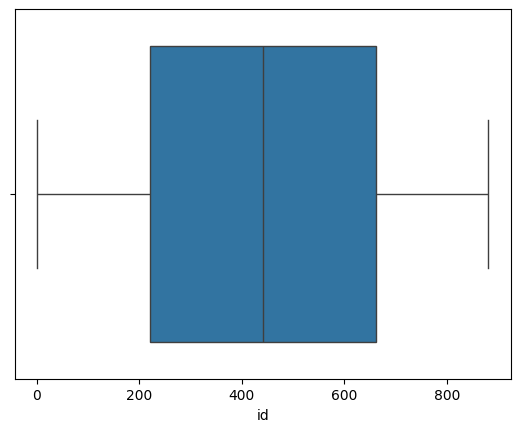

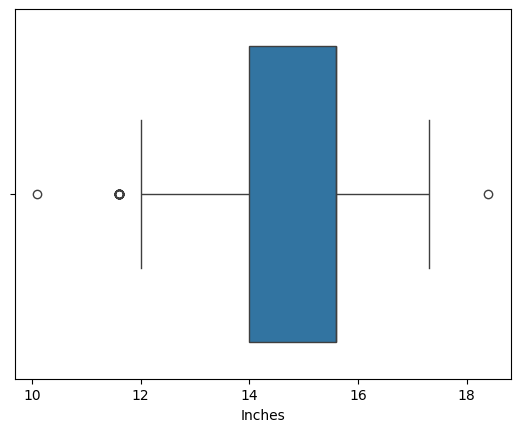

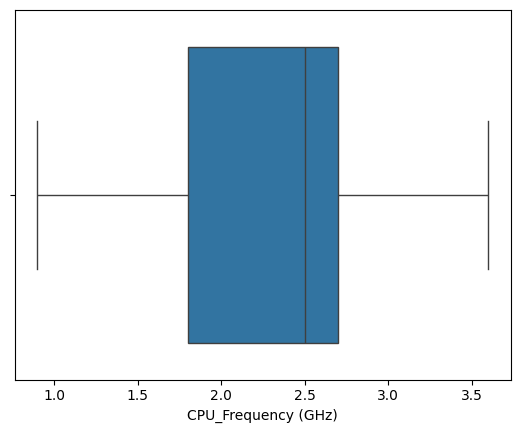

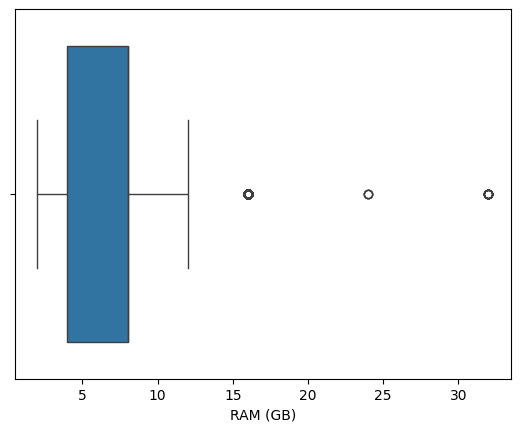

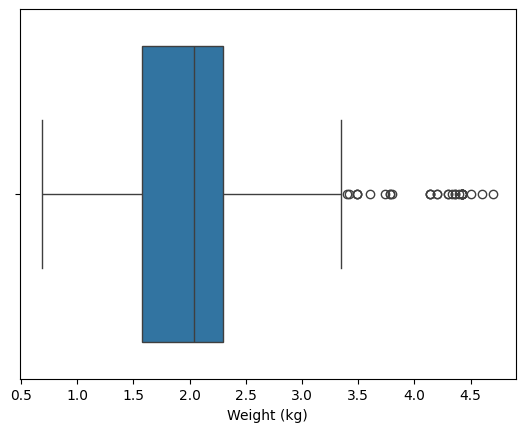

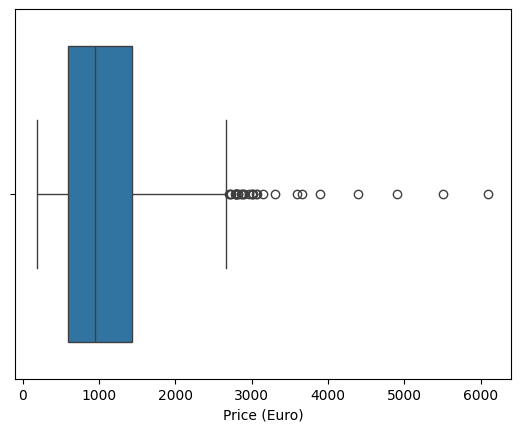

In [1271]:
for i in train_df.select_dtypes(include="number").columns:
  sns.boxplot(data=train_df, x=i)
  plt.show()

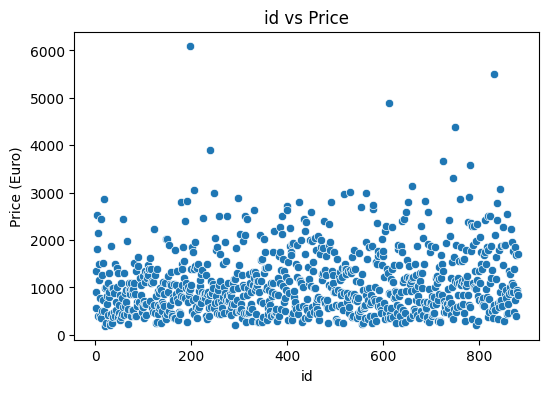

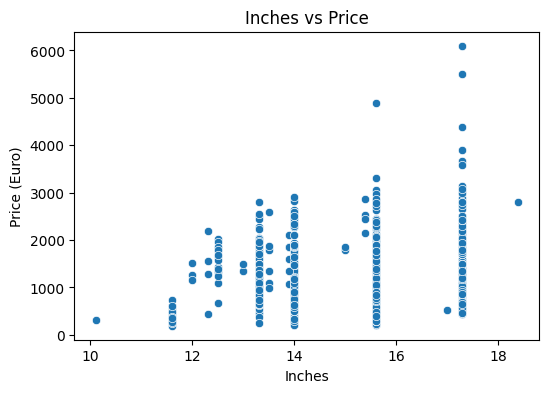

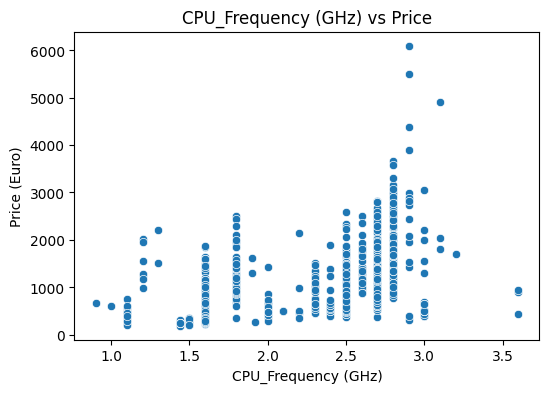

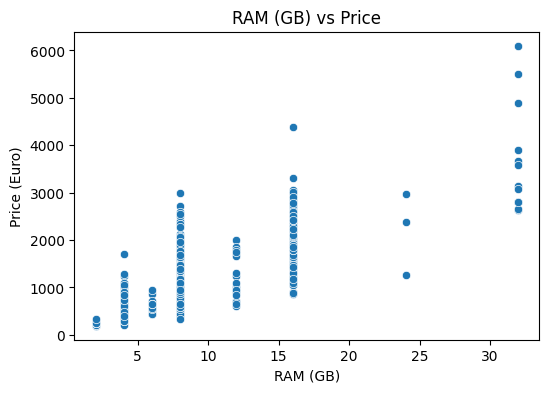

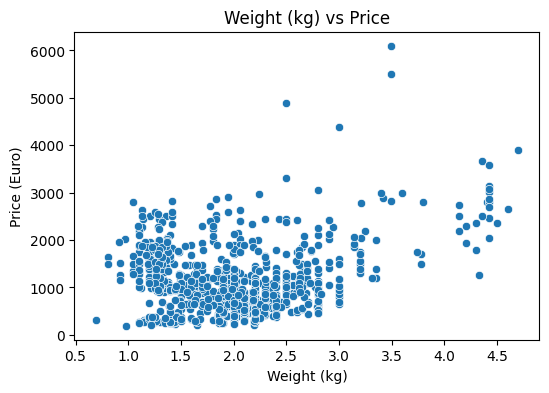

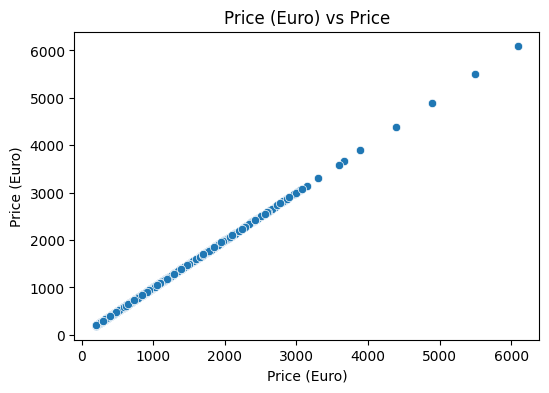

In [1272]:
for col in train_df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=train_df, x=col, y='Price (Euro)')
    plt.title(f'{col} vs Price')
    plt.show()

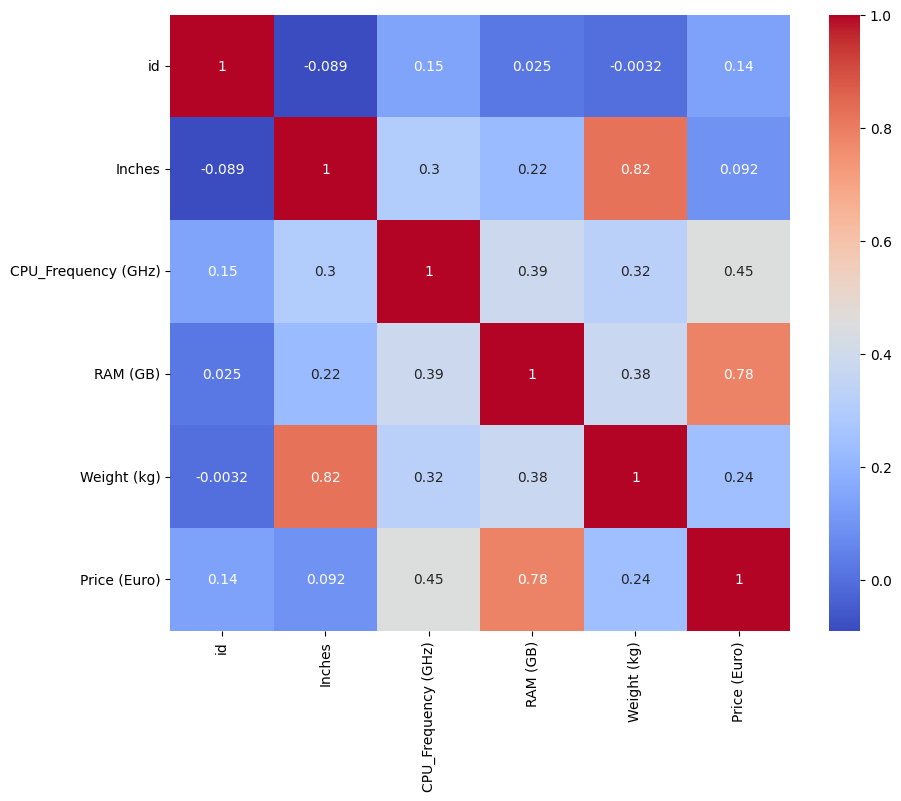

In [1273]:
numeric_df=train_df.select_dtypes(include="number")
numeric_df.head()
corr_df=numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.show()

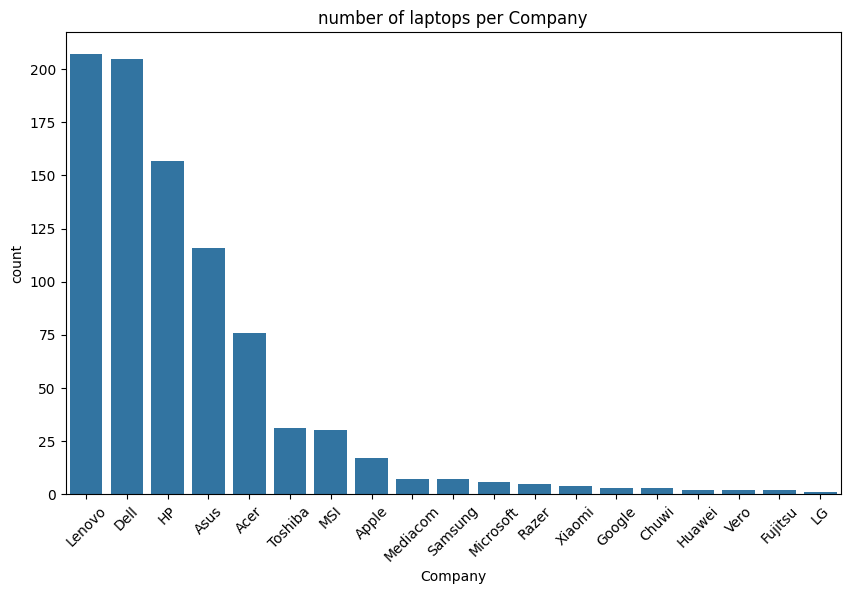

In [1274]:
plt.figure(figsize=(10,6))
sns.countplot(data=train_df,x="Company",order=train_df["Company"].value_counts().index)
plt.xticks(rotation=45)
plt.title("number of laptops per Company")
plt.show()

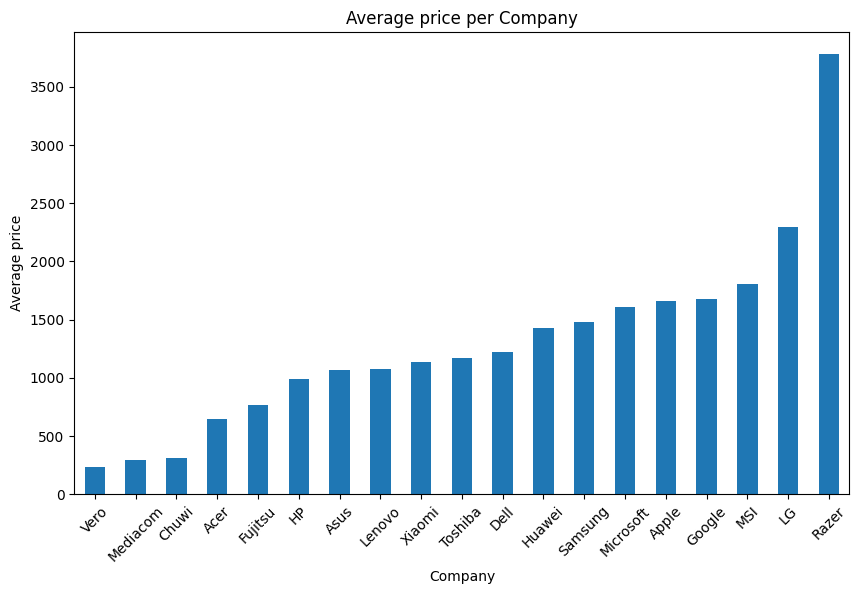

In [1275]:
plt.figure(figsize=(10,6))
avg_price=train_df.groupby("Company")["Price (Euro)"].mean().sort_values()
avg_price.plot(kind="bar")
plt.title("Average price per Company")
plt.ylabel("Average price")
plt.xticks(rotation=45)
plt.show()

# **Data Preparation**

**Preprocessing**

In [1276]:
y = train_df["Price (Euro)"].copy()

test_ids = test_df["id"].copy()

X = train_df.drop(columns=["Price (Euro)"]).copy()

X = X.drop(columns=["id"])
test_features = test_df.drop(columns=["id"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("test_features shape:", test_features.shape)

print("\nRemaining columns:")
print(X.columns.tolist())

X shape: (881, 14)
y shape: (881,)
test_features shape: (394, 14)

Remaining columns:
['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)']


**Feature Engineering**

Screen Resolution

In [1277]:
def screen_resolution_features(df):
    df = df.copy()

    df["is_ips"] = df["ScreenResolution"].str.contains("IPS", case=False, na=False).astype(int)
    df["is_touch"] = df["ScreenResolution"].str.contains("Touchscreen", case=False, na=False).astype(int)

    resolution = df["ScreenResolution"].str.extract(r"(\d{3,4})x(\d{3,4})")
    df["res_width"] = pd.to_numeric(resolution[0], errors="coerce")
    df["res_height"] = pd.to_numeric(resolution[1], errors="coerce")

    df["ppi"] = np.sqrt(df["res_width"]**2 + df["res_height"]**2) / df["Inches"]

    df = df.drop(columns=["ScreenResolution","Inches","res_height","res_width"])

    return df
X = screen_resolution_features(X)
test_features = screen_resolution_features(test_features)

print("\nMissing values after screen engineering:")


Missing values after screen engineering:


Calculating Memory

In [1278]:
def convert_to_gb(size, unit):
    size = float(size)
    if unit.upper() == "TB":
        return size * 1024
    return size

def parse_memory_column(df):
    df = df.copy()

    ssd_list = []
    hdd_list = []
    flash_list = []
    hybrid_list = []

    for value in df["Memory"]:
        ssd = 0
        hdd = 0
        flash = 0
        hybrid = 0

        text = str(value).upper().strip()
        parts = re.split(r"\s*\+\s*", text)

        for part in parts:
            match = re.search(r"(\d+(?:\.\d+)?)\s*(GB|TB)", part)
            if not match:
                continue

            size = convert_to_gb(match.group(1), match.group(2))

            if "SSD" in part:
                ssd += size
            elif "HDD" in part:
                hdd += size
            elif "HYBRID" in part:
                hybrid += size
            elif "FLASH STORAGE" in part or "EMMC" in part:
                flash += size
            else:
                # fallback for uncommon labels
                flash += size

        ssd_list.append(ssd)
        hdd_list.append(hdd)
        flash_list.append(flash)
        hybrid_list.append(hybrid)

    df["ssd_gb"] = ssd_list
    df["hdd_gb"] = hdd_list
    df["flash_gb"] = flash_list
    df["hybrid_gb"] = hybrid_list

    df["total_storage_gb"] = df["ssd_gb"] + df["hdd_gb"] + df["flash_gb"] + df["hybrid_gb"]

    df["has_ssd"] = (df["ssd_gb"] > 0).astype(int)
    df["has_hdd"] = (df["hdd_gb"] > 0).astype(int)
    df["has_flash"] = (df["flash_gb"] > 0).astype(int)
    df["has_hybrid"] = (df["hybrid_gb"] > 0).astype(int)

    df = df.drop(columns=["Memory"])
    return df

X = parse_memory_column(X)
test_features = parse_memory_column(test_features)

print(
    X[
        [
            "ssd_gb", "hdd_gb", "flash_gb", "hybrid_gb",
            "total_storage_gb", "has_ssd", "has_hdd", "has_flash", "has_hybrid"
        ]
    ].head(10)
)

print("\nMissing values after memory engineering:")
print(
    X[
        [
            "ssd_gb", "hdd_gb", "flash_gb", "hybrid_gb",
            "total_storage_gb"
        ]
    ].isnull().sum()
)

   ssd_gb  hdd_gb  flash_gb  hybrid_gb  total_storage_gb  has_ssd  has_hdd  \
0   128.0     0.0       0.0        0.0             128.0        1        0   
1     0.0     0.0     128.0        0.0             128.0        0        0   
2   256.0     0.0       0.0        0.0             256.0        1        0   
3   512.0     0.0       0.0        0.0             512.0        1        0   
4   256.0     0.0       0.0        0.0             256.0        1        0   
5     0.0   500.0       0.0        0.0             500.0        0        1   
6     0.0     0.0     256.0        0.0             256.0        0        0   
7     0.0     0.0     256.0        0.0             256.0        0        0   
8   512.0     0.0       0.0        0.0             512.0        1        0   
9   256.0     0.0       0.0        0.0             256.0        1        0   

   has_flash  has_hybrid  
0          0           0  
1          1           0  
2          0           0  
3          0           0  
4     

separating cpu type

In [1279]:
def extract_cpu_family(text):
    text = str(text).upper()

    if "CORE I7" in text:
        return "Core i7"
    elif "CORE I5" in text:
        return "Core i5"
    elif "CORE I3" in text:
        return "Core i3"
    elif "CORE M" in text:
        return "Core M"
    elif "CELERON" in text:
        return "Celeron"
    elif "PENTIUM" in text:
        return "Pentium"
    elif "RYZEN" in text:
        return "Ryzen"
    elif "XEON" in text:
        return "Xeon"
    elif "ATOM" in text:
        return "Atom"
    elif "A12-SERIES" in text:
        return "A12-Series"
    elif "A10-SERIES" in text:
        return "A10-Series"
    elif "A9-SERIES" in text:
        return "A9-Series"
    elif "A8-SERIES" in text:
        return "A8-Series"
    elif "A6-SERIES" in text:
        return "A6-Series"
    elif "E-SERIES" in text:
        return "E-Series"
    elif "FX" in text:
        return "FX"
    else:
        return "Other"

def extract_cpu_core_class(text):
    text = str(text).upper()
    if "DUAL CORE" in text:
        return "Dual"
    elif "QUAD CORE" in text:
        return "Quad"
    else:
        return "None"

def extract_cpu_suffix(text):
    text = str(text).upper()

    # Common laptop suffixes
    match = re.search(r"\d+(HQ|HK|U|Y|M|P|G)\b", text)
    if match:
        return match.group(1)

    # Some CPUs may contain suffix after hyphen
    match2 = re.search(r"\b(HQ|HK|U|Y|M|P|G)\b", text)
    if match2:
        return match2.group(1)

    return "None"

def extract_cpu_generation(text):
    text = str(text).upper()

    family = extract_cpu_family(text)

    # safest for Intel Core family
    if family in ["Core i3", "Core i5", "Core i7", "Core M"]:
        match = re.search(r"\b(\d{4,5})[A-Z]*\b", text)
        if match:
            num = match.group(1)

            # 7500U -> 7, 8250U -> 8, 6Y75 -> 6, 7Y30 -> 7
            if len(num) == 4:
                return num[0]
            elif len(num) == 5:
                return num[:2]

    return "Unknown"

def cpu_features(df):
    df = df.copy()

    df["cpu_family"] = df["CPU_Type"].apply(extract_cpu_family)
    df["cpu_core_class"] = df["CPU_Type"].apply(extract_cpu_core_class)
    df["cpu_suffix"] = df["CPU_Type"].apply(extract_cpu_suffix)
    df["cpu_generation"] = df["CPU_Type"].apply(extract_cpu_generation)

    df = df.drop(columns=["CPU_Type"])
    return df

X = cpu_features(X)
test_features = cpu_features(test_features)

print(X[["cpu_family", "cpu_core_class", "cpu_suffix", "cpu_generation"]].head(15))

print("\nTrain CPU family counts:")
print(X["cpu_family"].value_counts())

print("\nTrain CPU suffix counts:")
print(X["cpu_suffix"].value_counts())

print("\nTrain CPU generation counts:")
print(X["cpu_generation"].value_counts())

   cpu_family cpu_core_class cpu_suffix cpu_generation
0     Core i5           None       None        Unknown
1     Core i5           None       None        Unknown
2     Core i5           None          U              7
3     Core i7           None       None        Unknown
4     Core i5           None       None        Unknown
5   A9-Series           None       None        Unknown
6     Core i7           None       None        Unknown
7     Core i5           None       None        Unknown
8     Core i7           None          U              8
9     Core i5           None          U              8
10    Core i5           None          U              7
11    Core i3           None          U              6
12    Core i7           None       None        Unknown
13    Core i3           None          U              6
14     Core M           None          M        Unknown

Train CPU family counts:
cpu_family
Core i7       350
Core i5       292
Core i3        98
Celeron        57
Pentium    

product

In [1280]:
def extract_product_series(text):
    text = str(text).strip()
    if text == "" or text.lower() == "nan":
        return "Unknown"
    return text.split()[0]

def extract_gpu_series(text):
    text = str(text).upper()

    if "GTX" in text:
        return "GTX"
    elif "RTX" in text:
        return "RTX"
    elif "MX" in text:
        return "MX"
    elif "QUADRO" in text:
        return "Quadro"
    elif "IRIS" in text:
        return "Iris"
    elif "UHD" in text:
        return "UHD"
    elif "HD GRAPHICS" in text or re.search(r"\bHD\b", text):
        return "HD Graphics"
    elif "RADEON" in text:
        return "Radeon"
    elif "RX" in text:
        return "RX"
    elif "FIREPRO" in text:
        return "FirePro"
    elif "GEFORCE" in text:
        return "GeForce"
    else:
        return "Other"

def gpu_product_features(df):
    df = df.copy()

    df["product_series"] = df["Product"].apply(extract_product_series)
    df["gpu_series"] = df["GPU_Type"].apply(extract_gpu_series)

    df = df.drop(columns=["Product", "GPU_Type"])
    return df

X = gpu_product_features(X)
test_features = gpu_product_features(test_features)

print(X[["product_series", "gpu_series"]].head(15))

print("\nTop product series:")
print(X["product_series"].value_counts().head(20))

print("\nGPU series counts:")
print(X["gpu_series"].value_counts())

   product_series   gpu_series
0         MacBook         Iris
1         Macbook  HD Graphics
2             250  HD Graphics
3         MacBook       Radeon
4         MacBook         Iris
5          Aspire       Radeon
6         MacBook         Iris
7         Macbook  HD Graphics
8         ZenBook           MX
9           Swift          UHD
10            250  HD Graphics
11            250  HD Graphics
12        MacBook       Radeon
13       Inspiron       Radeon
14        MacBook  HD Graphics

Top product series:
product_series
Inspiron     100
IdeaPad       64
Aspire        47
ThinkPad      39
Latitude      34
Thinkpad      33
ProBook       28
XPS           25
Vostro        20
Legion        19
EliteBook     19
Yoga          18
VivoBook      18
250           17
MacBook       15
ZenBook       14
Alienware     14
Satellite     13
Rog           13
Probook       11
Name: count, dtype: int64

GPU series counts:
gpu_series
HD Graphics    385
GTX            159
Radeon         129
MX            

In [1281]:
def clean_text_categories(df):
    df = df.copy()

    product_map = {
        "Macbook": "MacBook",
        "Thinkpad": "ThinkPad",
        "Probook": "ProBook",
        "Rog": "ROG",
        "Vivobook": "VivoBook"
    }
    df["product_series"] = df["product_series"].replace(product_map)

    df["OpSys"] = df["OpSys"].replace({
        "Mac OS X": "macOS",
        "macOS": "macOS"
    })

    return df
X = clean_text_categories(X)
test_features = clean_text_categories(test_features)

print("Top product series after cleaning:")

print("\nUnique values in OpSys:")
print(X["OpSys"].value_counts())

Top product series after cleaning:

Unique values in OpSys:
OpSys
Windows 10      735
No OS            50
Linux            45
macOS            17
Chrome OS        17
Windows 10 S      8
Windows 7         8
Android           1
Name: count, dtype: int64


In [1282]:
print("X shape:", X.shape)
print("test_features shape:", test_features.shape)
print("y shape:", y.shape)

print("\nColumns in X:")
print(X.columns.tolist())

print("\nMissing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nMissing values in test_features:")
print(test_features.isnull().sum()[test_features.isnull().sum() > 0])

print("\nColumns mismatch check:")
print("Only in X:", set(X.columns) - set(test_features.columns))
print("Only in test_features:", set(test_features.columns) - set(X.columns))

display(X.head())

X shape: (881, 26)
test_features shape: (394, 26)
y shape: (881,)

Columns in X:
['Company', 'TypeName', 'CPU_Company', 'CPU_Frequency (GHz)', 'RAM (GB)', 'GPU_Company', 'OpSys', 'Weight (kg)', 'is_ips', 'is_touch', 'ppi', 'ssd_gb', 'hdd_gb', 'flash_gb', 'hybrid_gb', 'total_storage_gb', 'has_ssd', 'has_hdd', 'has_flash', 'has_hybrid', 'cpu_family', 'cpu_core_class', 'cpu_suffix', 'cpu_generation', 'product_series', 'gpu_series']

Missing values in X:
Series([], dtype: int64)

Missing values in test_features:
Series([], dtype: int64)

Columns mismatch check:
Only in X: set()
Only in test_features: set()


,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),is_ips,is_touch,...,has_ssd,has_hdd,has_flash,has_hybrid,cpu_family,cpu_core_class,cpu_suffix,cpu_generation,product_series,gpu_series
0,Apple,Ultrabook,Intel,2.3,8,Intel,macOS,1.37,1,0,...,1,0,0,0,Core i5,None,None,Unknown,MacBook,Iris
1,Apple,Ultrabook,Intel,1.8,8,Intel,macOS,1.34,0,0,...,0,0,1,0,Core i5,None,None,Unknown,MacBook,HD Graphics
2,HP,Notebook,Intel,2.5,8,Intel,No OS,1.86,0,0,...,1,0,0,0,Core i5,None,U,7,250,HD Graphics
3,Apple,Ultrabook,Intel,2.7,16,AMD,macOS,1.83,1,0,...,1,0,0,0,Core i7,None,None,Unknown,MacBook,Radeon
4,Apple,Ultrabook,Intel,3.1,8,Intel,macOS,1.37,1,0,...,1,0,0,0,Core i5,None,None,Unknown,MacBook,Iris


In [1283]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(numerical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))

Categorical columns:
['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'OpSys', 'cpu_family', 'cpu_core_class', 'cpu_suffix', 'cpu_generation', 'product_series', 'gpu_series']

Number of categorical columns: 11

Numerical columns:
['CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'is_ips', 'is_touch', 'ppi', 'ssd_gb', 'hdd_gb', 'flash_gb', 'hybrid_gb', 'total_storage_gb', 'has_ssd', 'has_hdd', 'has_flash', 'has_hybrid']

Number of numerical columns: 15


In [1284]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessor for linear-style models
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Preprocessor for tree model
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Linear preprocessor created.")
print("Tree preprocessor created.")

Linear preprocessor created.
Tree preprocessor created.


In [1285]:
from sklearn.model_selection import train_test_split

# Holdout split
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Log-transform target for experiments
y_train_main_log = np.log1p(y_train_main)
y_val_log = np.log1p(y_val)

print("X_train_main shape:", X_train_main.shape)
print("X_val shape:", X_val.shape)
print("y_train_main shape:", y_train_main.shape)
print("y_val shape:", y_val.shape)

print("\nOriginal target range:")
print("min =", y.min(), ", max =", y.max())

print("\nLog target range:")
print("min =", y_train_main_log.min(), ", max =", y_train_main_log.max())

X_train_main shape: (704, 26)
X_val shape: (177, 26)
y_train_main shape: (704,)
y_val shape: (177,)

Original target range:
min = 191.9 , max = 6099.0

Log target range:
min = 5.262171919911683 , max = 8.612503371220562


model

In [1286]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linear_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_cv_scores = cross_val_score(
    linear_model,
    X_train_main,
    y_train_main,
    cv=kf,
    scoring="r2"
)

print("Linear Regression CV R² scores:", linear_cv_scores)
print("Mean CV R²:", linear_cv_scores.mean())
print("Std CV R²:", linear_cv_scores.std())

Linear Regression CV R² scores: [0.77826068 0.82632613 0.88666773 0.87523293 0.83752425]
Mean CV R²: 0.8408023435045671
Std CV R²: 0.03852496650137002


In [1287]:
linear_model.fit(X_train_main, y_train_main)

y_val_pred_linear = linear_model.predict(X_val)

linear_val_r2 = r2_score(y_val, y_val_pred_linear)
linear_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_linear))
linear_val_mae = mean_absolute_error(y_val, y_val_pred_linear)

print("Linear Regression Validation R²:", linear_val_r2)
print("Linear Regression Validation RMSE:", linear_val_rmse)
print("Linear Regression Validation MAE:", linear_val_mae)

Linear Regression Validation R²: 0.8833162562034738
Linear Regression Validation RMSE: 267.3575073633183
Linear Regression Validation MAE: 177.63105405990635


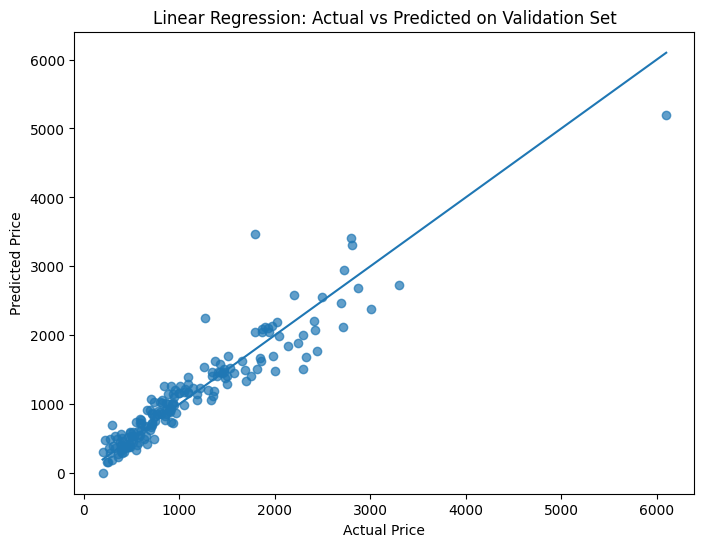

In [1288]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_linear, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted on Validation Set")
plt.show()

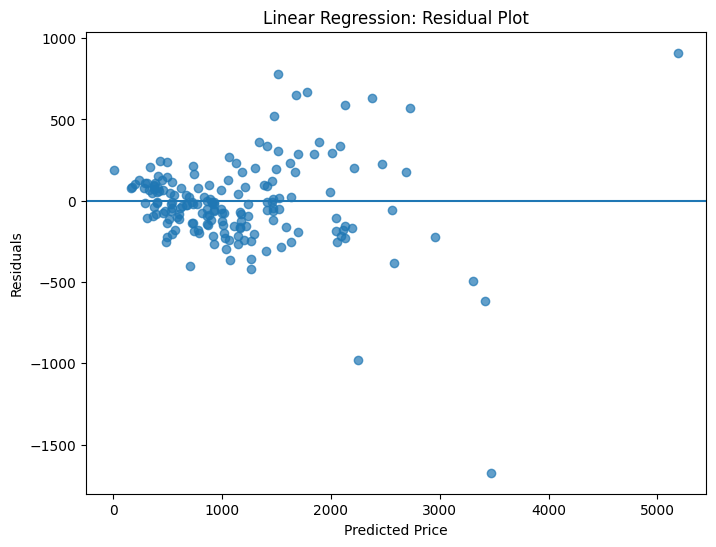

In [1289]:
linear_residuals = y_val - y_val_pred_linear

plt.figure(figsize=(8, 6))
plt.scatter(y_val_pred_linear, linear_residuals, alpha=0.7)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")
plt.show()

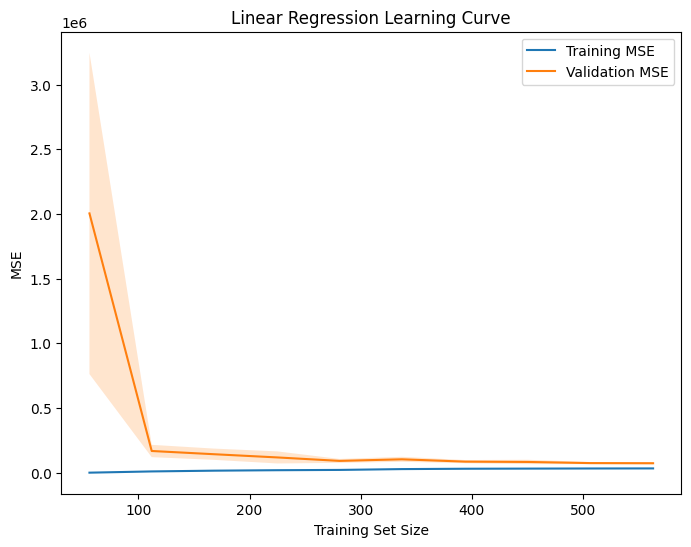

In [1290]:


train_sizes, train_scores, val_scores = learning_curve(
    estimator=linear_model,
    X=X_train_main,
    y=y_train_main,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

train_mse = -train_scores
val_mse = -val_scores

train_mse_mean = train_mse.mean(axis=1)
train_mse_std = train_mse.std(axis=1)

val_mse_mean = val_mse.mean(axis=1)
val_mse_std = val_mse.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mse_mean, label="Training MSE")
plt.plot(train_sizes, val_mse_mean, label="Validation MSE")

plt.fill_between(
    train_sizes,
    train_mse_mean - train_mse_std,
    train_mse_mean + train_mse_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mse_mean - val_mse_std,
    val_mse_mean + val_mse_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Linear Regression Learning Curve")
plt.legend()
plt.show()

In [1291]:
linear_results = {
    "Model": "Linear Regression",
    "CV_R2": linear_cv_scores.mean(),
    "Validation_R2": linear_val_r2,
    "Validation_RMSE": linear_val_rmse,
    "Validation_MAE": linear_val_mae
}
linear_results

{'Model': 'Linear Regression',
 'CV_R2': np.float64(0.8408023435045671),
 'Validation_R2': 0.8833162562034738,
 'Validation_RMSE': np.float64(267.3575073633183),
 'Validation_MAE': 177.63105405990635}

ridge model

In [1292]:
ridge_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_cv_scores = cross_val_score(
    ridge_model,
    X_train_main,
    y_train_main,
    cv=kf,
    scoring="r2"
)

print("Ridge Regression CV R² scores:", ridge_cv_scores)
print("Mean CV R²:", ridge_cv_scores.mean())
print("Std CV R²:", ridge_cv_scores.std())

Ridge Regression CV R² scores: [0.85623711 0.83711751 0.87552508 0.88968257 0.83990089]
Mean CV R²: 0.8596926323780518
Std CV R²: 0.020314295674299588


In [1293]:
ridge_model.fit(X_train_main, y_train_main)

y_val_pred_ridge_baseline = ridge_model.predict(X_val)

ridge_baseline_val_r2 = r2_score(y_val, y_val_pred_ridge_baseline)
ridge_baseline_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge_baseline))
ridge_baseline_val_mae = mean_absolute_error(y_val, y_val_pred_ridge_baseline)

print("Ridge Regression Validation R²:", ridge_baseline_val_r2)
print("Ridge Regression Validation RMSE:", ridge_baseline_val_rmse)
print("Ridge Regression Validation MAE:", ridge_baseline_val_mae)

Ridge Regression Validation R²: 0.8924646067535013
Ridge Regression Validation RMSE: 256.66279530700183
Ridge Regression Validation MAE: 169.1291698956372


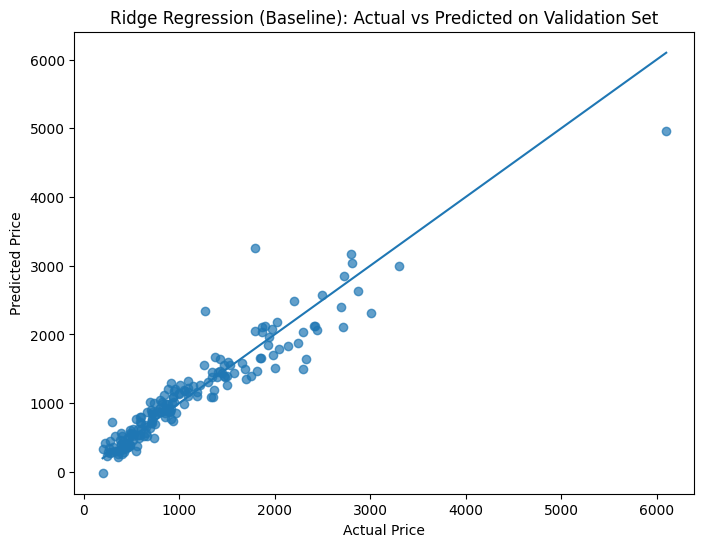

In [1294]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_ridge_baseline, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression (Baseline): Actual vs Predicted on Validation Set")
plt.show()

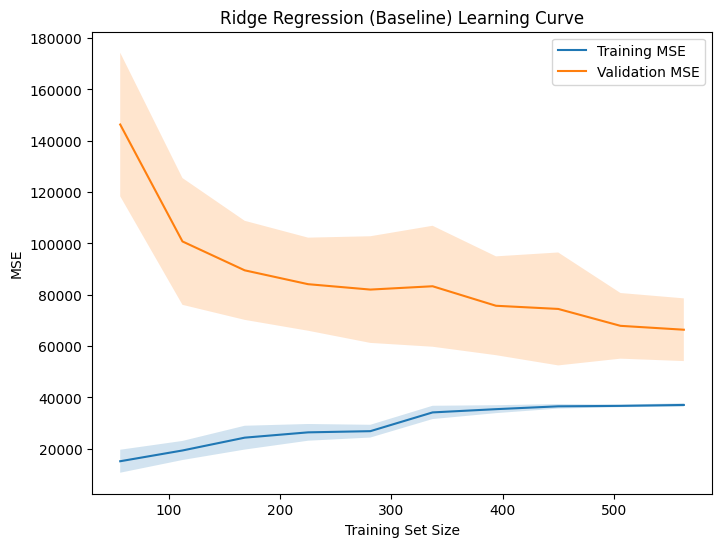

In [1295]:
train_sizes_ridge, train_scores_ridge, val_scores_ridge = learning_curve(
    estimator=ridge_model,
    X=X_train_main,
    y=y_train_main,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

train_mse_ridge = -train_scores_ridge
val_mse_ridge = -val_scores_ridge

train_mse_ridge_mean = train_mse_ridge.mean(axis=1)
train_mse_ridge_std = train_mse_ridge.std(axis=1)

val_mse_ridge_mean = val_mse_ridge.mean(axis=1)
val_mse_ridge_std = val_mse_ridge.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_ridge, train_mse_ridge_mean, label="Training MSE")
plt.plot(train_sizes_ridge, val_mse_ridge_mean, label="Validation MSE")

plt.fill_between(
    train_sizes_ridge,
    train_mse_ridge_mean - train_mse_ridge_std,
    train_mse_ridge_mean + train_mse_ridge_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes_ridge,
    val_mse_ridge_mean - val_mse_ridge_std,
    val_mse_ridge_mean + val_mse_ridge_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Ridge Regression (Baseline) Learning Curve")
plt.legend()
plt.show()

In [1296]:
ridge_baseline_results = {
    "Model": "Ridge (baseline)",
    "CV_R2": ridge_cv_scores.mean(),
    "Validation_R2": ridge_baseline_val_r2,
    "Validation_RMSE": ridge_baseline_val_rmse,
    "Validation_MAE": ridge_baseline_val_mae
}

ridge_baseline_results

{'Model': 'Ridge (baseline)',
 'CV_R2': np.float64(0.8596926323780518),
 'Validation_R2': 0.8924646067535013,
 'Validation_RMSE': np.float64(256.66279530700183),
 'Validation_MAE': 169.1291698956372}

lasso

In [1297]:
lasso_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Lasso(alpha=0.0005, max_iter=50000))
])

lasso_cv_scores = cross_val_score(
    lasso_model,
    X_train_main,
    y_train_main,
    cv=kf,
    scoring="r2"
)

print("Lasso Regression CV R² scores:", lasso_cv_scores)
print("Mean CV R²:", lasso_cv_scores.mean())
print("Std CV R²:", lasso_cv_scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 700339.5763021614, tolerance: 28705.836610469705
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 637022.4194483422, tolerance: 27022.52901336643
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso Regression CV R² scores: [0.77880397 0.8268919  0.88521979 0.87483767 0.83567243]
Mean CV R²: 0.8402851498392276
Std CV R²: 0.037930438004725425


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 322803.882819321, tolerance: 27268.5005013166
  model = cd_fast.sparse_enet_coordinate_descent(


In [1298]:
lasso_model.fit(X_train_main, y_train_main)

y_val_pred_lasso = lasso_model.predict(X_val)

lasso_val_r2 = r2_score(y_val, y_val_pred_lasso)
lasso_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
lasso_val_mae = mean_absolute_error(y_val, y_val_pred_lasso)

print("Lasso Regression Validation R²:", lasso_val_r2)
print("Lasso Regression Validation RMSE:", lasso_val_rmse)
print("Lasso Regression Validation MAE:", lasso_val_mae)

Lasso Regression Validation R²: 0.881816034025586
Lasso Regression Validation RMSE: 269.0707479254904
Lasso Regression Validation MAE: 177.14544688352484


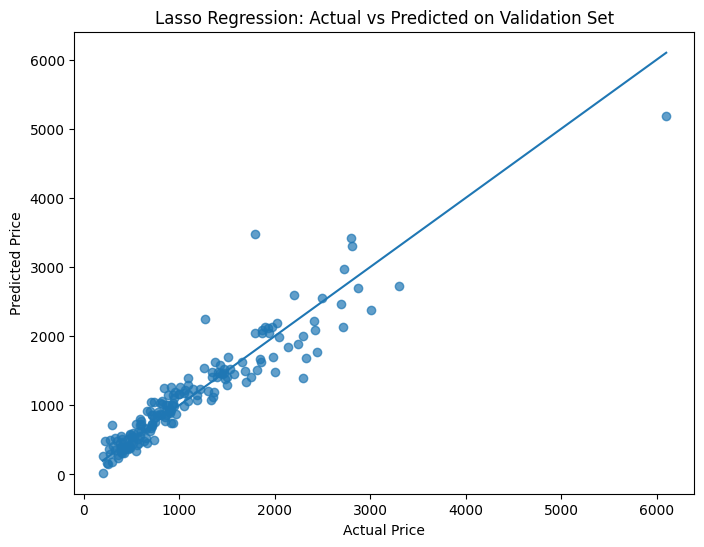

In [1299]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_lasso, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted on Validation Set")
plt.show()

In [1300]:
lasso_results = {
    "Model": "Lasso",
    "CV_R2": lasso_cv_scores.mean(),
    "Validation_R2": lasso_val_r2,
    "Validation_RMSE": lasso_val_rmse,
    "Validation_MAE": lasso_val_mae
}

lasso_results

{'Model': 'Lasso',
 'CV_R2': np.float64(0.8402851498392276),
 'Validation_R2': 0.881816034025586,
 'Validation_RMSE': np.float64(269.0707479254904),
 'Validation_MAE': 177.14544688352484}

Tree

In [1301]:
tree_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

tree_cv_scores = cross_val_score(
    tree_model,
    X_train_main,
    y_train_main,
    cv=kf,
    scoring="r2"
)

print("Decision Tree CV R² scores:", tree_cv_scores)
print("Mean CV R²:", tree_cv_scores.mean())
print("Std CV R²:", tree_cv_scores.std())

Decision Tree CV R² scores: [0.82025792 0.73973061 0.70688519 0.75190731 0.6010183 ]
Mean CV R²: 0.7239598670173648
Std CV R²: 0.07170671679345607


In [1302]:
tree_model.fit(X_train_main, y_train_main)

y_val_pred_tree_baseline = tree_model.predict(X_val)

tree_baseline_val_r2 = r2_score(y_val, y_val_pred_tree_baseline)
tree_baseline_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_tree_baseline))
tree_baseline_val_mae = mean_absolute_error(y_val, y_val_pred_tree_baseline)

print("Decision Tree Validation R²:", tree_baseline_val_r2)
print("Decision Tree Validation RMSE:", tree_baseline_val_rmse)
print("Decision Tree Validation MAE:", tree_baseline_val_mae)

Decision Tree Validation R²: 0.8693904474446335
Decision Tree Validation RMSE: 282.8620450006434
Decision Tree Validation MAE: 174.52568738229755


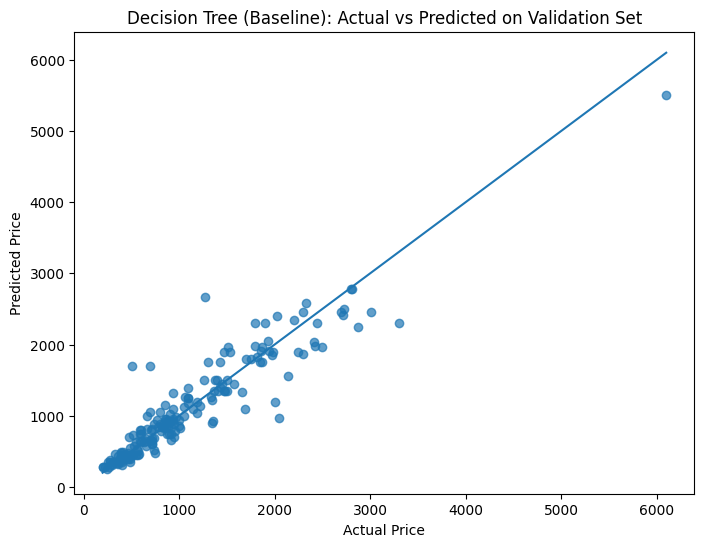

In [1303]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_tree_baseline, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree (Baseline): Actual vs Predicted on Validation Set")
plt.show()

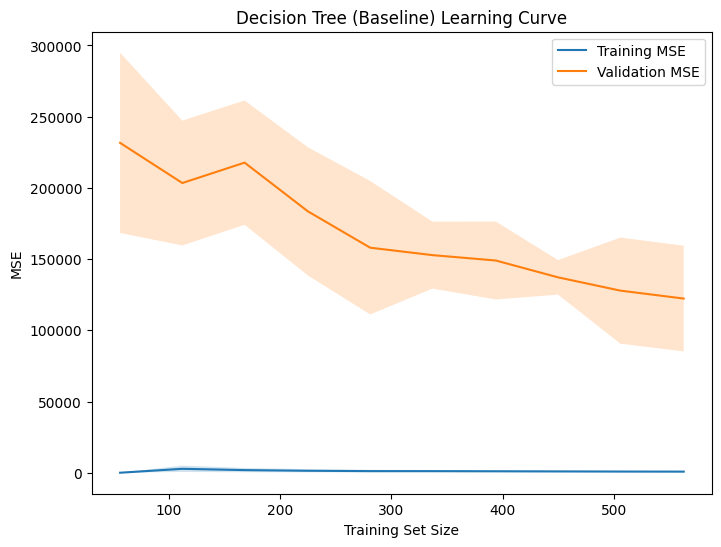

In [1304]:
train_sizes_tree, train_scores_tree, val_scores_tree = learning_curve(
    estimator=tree_model,
    X=X_train_main,
    y=y_train_main,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

train_mse_tree = -train_scores_tree
val_mse_tree = -val_scores_tree

train_mse_tree_mean = train_mse_tree.mean(axis=1)
train_mse_tree_std = train_mse_tree.std(axis=1)

val_mse_tree_mean = val_mse_tree.mean(axis=1)
val_mse_tree_std = val_mse_tree.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_tree, train_mse_tree_mean, label="Training MSE")
plt.plot(train_sizes_tree, val_mse_tree_mean, label="Validation MSE")

plt.fill_between(
    train_sizes_tree,
    train_mse_tree_mean - train_mse_tree_std,
    train_mse_tree_mean + train_mse_tree_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes_tree,
    val_mse_tree_mean - val_mse_tree_std,
    val_mse_tree_mean + val_mse_tree_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Decision Tree (Baseline) Learning Curve")
plt.legend()
plt.show()

In [1305]:
tree_baseline_results = {
    "Model": "Decision Tree (baseline)",
    "CV_R2": tree_cv_scores.mean(),
    "Validation_R2": tree_baseline_val_r2,
    "Validation_RMSE": tree_baseline_val_rmse,
    "Validation_MAE": tree_baseline_val_mae
}

tree_baseline_results

{'Model': 'Decision Tree (baseline)',
 'CV_R2': np.float64(0.7239598670173648),
 'Validation_R2': 0.8693904474446335,
 'Validation_RMSE': np.float64(282.8620450006434),
 'Validation_MAE': 174.52568738229755}

polynomyal

In [1306]:
poly_features = ["CPU_Frequency (GHz)", "RAM (GB)", "Weight (kg)", "ppi", "total_storage_gb"]

X_train_poly = X_train_main[poly_features].copy()

poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_cv_scores = cross_val_score(
    poly_model,
    X_train_poly,
    y_train_main,
    cv=kf,
    scoring="r2"
)

print("Polynomial Regression CV R² scores:", poly_cv_scores)
print("Mean CV R²:", poly_cv_scores.mean())
print("Std CV R²:", poly_cv_scores.std())

Polynomial Regression CV R² scores: [0.71551995 0.69376139 0.74932826 0.75533525 0.69765039]
Mean CV R²: 0.7223190479639665
Std CV R²: 0.025651033129478893


In [1307]:
X_val_poly = X_val[poly_features].copy()

poly_model.fit(X_train_poly, y_train_main)

y_val_pred_poly = poly_model.predict(X_val_poly)

poly_val_r2 = r2_score(y_val, y_val_pred_poly)
poly_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_poly))
poly_val_mae = mean_absolute_error(y_val, y_val_pred_poly)

print("Polynomial Regression Validation R²:", poly_val_r2)
print("Polynomial Regression Validation RMSE:", poly_val_rmse)
print("Polynomial Regression Validation MAE:", poly_val_mae)

Polynomial Regression Validation R²: 0.7367751435183217
Polynomial Regression Validation RMSE: 401.56019348683776
Polynomial Regression Validation MAE: 268.1022483454908


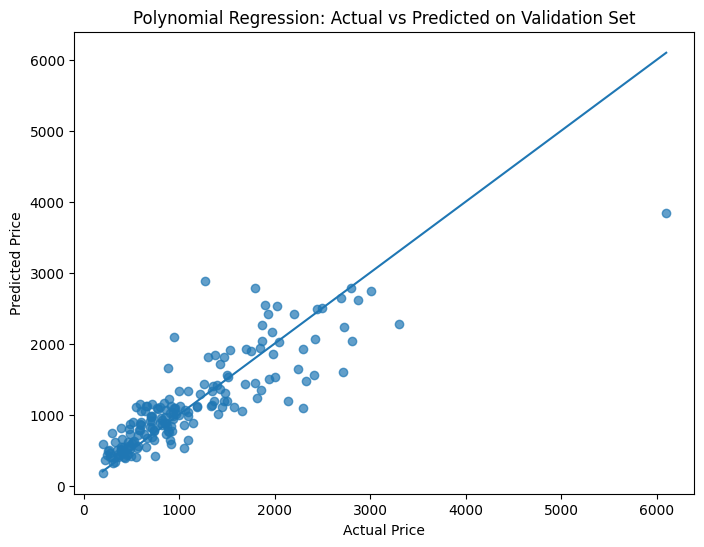

In [1308]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_poly, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Polynomial Regression: Actual vs Predicted on Validation Set")
plt.show()

ridge tuning

In [1309]:
ridge_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_main, y_train_main)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge CV R²:", ridge_grid.best_score_)

Best Ridge alpha: {'model__alpha': 1}
Best Ridge CV R²: 0.8596926323780518


In [1310]:
best_ridge_model_tuned = ridge_grid.best_estimator_

best_ridge_model_tuned.fit(X_train_main, y_train_main)

y_val_pred_ridge_tuned = best_ridge_model_tuned.predict(X_val)

ridge_tuned_val_r2 = r2_score(y_val, y_val_pred_ridge_tuned)
ridge_tuned_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge_tuned))
ridge_tuned_val_mae = mean_absolute_error(y_val, y_val_pred_ridge_tuned)

print("Tuned Ridge Validation R²:", ridge_tuned_val_r2)
print("Tuned Ridge Validation RMSE:", ridge_tuned_val_rmse)
print("Tuned Ridge Validation MAE:", ridge_tuned_val_mae)

Tuned Ridge Validation R²: 0.8924646067535013
Tuned Ridge Validation RMSE: 256.66279530700183
Tuned Ridge Validation MAE: 169.1291698956372


ridge log1p

In [1311]:
best_ridge_log_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=0.1))
])

best_ridge_log_model.fit(X_train_main, y_train_main_log)

y_val_pred_log = best_ridge_log_model.predict(X_val)
y_val_pred_log_back = np.expm1(y_val_pred_log)
y_val_pred_log_back = np.maximum(y_val_pred_log_back, 0)

ridge_log_val_r2 = r2_score(y_val, y_val_pred_log_back)
ridge_log_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_log_back))
ridge_log_val_mae = mean_absolute_error(y_val, y_val_pred_log_back)

print("Log-Ridge Validation R²:", ridge_log_val_r2)
print("Log-Ridge Validation RMSE:", ridge_log_val_rmse)
print("Log-Ridge Validation MAE:", ridge_log_val_mae)

Log-Ridge Validation R²: 0.9098570511659773
Log-Ridge Validation RMSE: 234.99200487005882
Log-Ridge Validation MAE: 149.58971256616155


tree tuning

In [1312]:
from scipy.stats import randint

tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

tree_param_dist = {
    "model__max_depth": randint(3, 25),
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": [None, "sqrt", "log2"]
}

tree_random = RandomizedSearchCV(
    estimator=tree_pipeline,
    param_distributions=tree_param_dist,
    n_iter=30,
    cv=kf,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tree_random.fit(X_train_main, y_train_main)

print("Best Tree params:", tree_random.best_params_)
print("Best Tree CV R²:", tree_random.best_score_)

Best Tree params: {'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 16}
Best Tree CV R²: 0.7593792550620491


In [1313]:
best_tree_model_tuned = tree_random.best_estimator_

best_tree_model_tuned.fit(X_train_main, y_train_main)

y_val_pred_tree_tuned = best_tree_model_tuned.predict(X_val)

tree_tuned_val_r2 = r2_score(y_val, y_val_pred_tree_tuned)
tree_tuned_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_tree_tuned))
tree_tuned_val_mae = mean_absolute_error(y_val, y_val_pred_tree_tuned)

print("Tuned Tree Validation R²:", tree_tuned_val_r2)
print("Tuned Tree Validation RMSE:", tree_tuned_val_rmse)
print("Tuned Tree Validation MAE:", tree_tuned_val_mae)

Tuned Tree Validation R²: 0.753097443524876
Tuned Tree Validation RMSE: 388.9107962234808
Tuned Tree Validation MAE: 231.306202866427


comparison

In [1314]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (baseline)",
        "Lasso",
        "Decision Tree (baseline)",
        "Polynomial Regression",
        "Ridge (tuned)",
        "Decision Tree (tuned)",
        "Ridge (log target)"
    ],
    "CV_R2": [
        linear_cv_scores.mean(),
        ridge_cv_scores.mean(),
        lasso_cv_scores.mean(),
        tree_cv_scores.mean(),
        poly_cv_scores.mean(),
        ridge_grid.best_score_,
        tree_random.best_score_,
        np.nan
    ],
    "Validation_R2": [
        linear_val_r2,
        ridge_baseline_val_r2,
        lasso_val_r2,
        tree_baseline_val_r2,
        poly_val_r2,
        ridge_tuned_val_r2,
        tree_tuned_val_r2,
        ridge_log_val_r2
    ],
    "Validation_RMSE": [
        linear_val_rmse,
        ridge_baseline_val_rmse,
        lasso_val_rmse,
        tree_baseline_val_rmse,
        poly_val_rmse,
        ridge_tuned_val_rmse,
        tree_tuned_val_rmse,
        ridge_log_val_rmse
    ],
    "Validation_MAE": [
        linear_val_mae,
        ridge_baseline_val_mae,
        lasso_val_mae,
        tree_baseline_val_mae,
        poly_val_mae,
        ridge_tuned_val_mae,
        tree_tuned_val_mae,
        ridge_log_val_mae
    ]
})

final_results = final_results.sort_values(by="Validation_R2", ascending=False)
final_results

,Model,CV_R2,Validation_R2,Validation_RMSE,Validation_MAE
7,Ridge (log target),NaN,0.909857,234.992005,149.589713
1,Ridge (baseline),0.859693,0.892465,256.662795,169.129170
5,Ridge (tuned),0.859693,0.892465,256.662795,169.129170
0,Linear Regression,0.840802,0.883316,267.357507,177.631054
2,Lasso,0.840285,0.881816,269.070748,177.145447
3,Decision Tree (baseline),0.723960,0.869390,282.862045,174.525687
6,Decision Tree (tuned),0.759379,0.753097,388.910796,231.306203
4,Polynomial Regression,0.722319,0.736775,401.560193,268.102248


# **Create Sub File**

In [1315]:
final_ridge_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=0.1))
])

final_ridge_model.fit(X, y)

test_predictions = final_ridge_model.predict(test_features)

print("Prediction shape:", test_predictions.shape)
print("First 10 predictions:")
print(test_predictions[:10])

Prediction shape: (394,)
First 10 predictions:
[ 661.09741442  191.62111573  742.41498111  356.64370136 1571.11143063
  431.74195354 1495.57175717  351.03208584  446.77585494  748.81975201]


In [1316]:
submission = pd.DataFrame({
    "id": test_ids,
    "Price": test_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("\nSubmission shape:", submission.shape)

    id        Price
0  882   661.097414
1  883   191.621116
2  884   742.414981
3  885   356.643701
4  886  1571.111431

Submission shape: (394, 2)
